# CSE 190 — Bonus Assignment

Due at **11:59PM April 27th, 2026**

The bouns assingment accounts for **5%** of the final grade.

Put your answers in solution sections, add missing code, run all code blocks.

Make sure you choose a runtime type with a GPU, e.g., T4 GPU. You don't need to subscrible to Colab Pro for such runtime type.

What to submit: Print the notebook with output, save as a PDF, and submit the PDF to CatCourse.

It is very important you include output in the PDF submitted.

Save a copy of this notebook in drive so you don't lose your work.






1. [1 point] Calculate the probability of the sentence **i want to eat lunch**, given the probabilities for a bi-gram language model. Assume P(i|\<s>)=0.19 with start-symbol \<s> and P(\</s>|lunch)= 0.40 with end-symbol \</s>. The conditional probability of the bi-gram is as follows, where the rows indicate previous word and the columns are current words.

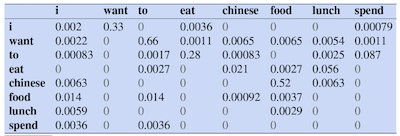

**Answer:**

Using the chain rule for bigrams, the probability of the sentence is the product of each conditional bigram probability:

$$P(\\text{i want to eat lunch}) = P(\\text{i}|\\langle s\\rangle) \\times P(\\text{want}|\\text{i}) \\times P(\\text{to}|\\text{want}) \\times P(\\text{eat}|\\text{to}) \\times P(\\text{lunch}|\\text{eat}) \\times P(\\langle/s\\rangle|\\text{lunch})$$

Reading values from the bigram table and the given probabilities:
- $P(\\text{i}|\\langle s\\rangle) = 0.19$ (given)
- $P(\\text{want}|\\text{i}) = 0.33$ (from table)
- $P(\\text{to}|\\text{want}) = 0.66$ (from table)
- $P(\\text{eat}|\\text{to}) = 0.28$ (from table)
- $P(\\text{lunch}|\\text{eat}) = 0.0054$ (from table)
- $P(\\langle/s\\rangle|\\text{lunch}) = 0.40$ (given)

$$P = 0.19 \\times 0.33 \\times 0.66 \\times 0.28 \\times 0.0054 \\times 0.40 \\approx 2.50 \\times 10^{-5}$$

2. [1 point] Which of the following are true about recurrent neural networks? Select all that apply. Briefly explain your answer.


a. Training recurrent neural networks can be impeded by the exploding gradient problem

b. Unlike standard feedforward networks, recurrent neural networks can learn from sequences of variable length.

c. Gradient clipping might help if your RNN is troubled by vanishing gradients.

d. None of the above

**Answer:**

**a. True.** RNNs are indeed susceptible to the *exploding gradient* problem. When gradients are back-propagated through many time steps, repeated matrix multiplications can cause them to grow exponentially, making training unstable. Gradient clipping is a standard remedy for this issue.

**b. True.** Unlike feedforward networks that require fixed-size inputs, RNNs process sequences step by step using a hidden state, so they naturally handle sequences of any length (e.g., sentences of different numbers of words).

**c. False.** Gradient clipping addresses the *exploding* gradient problem (truncating overly large gradient norms), not the *vanishing* gradient problem. Vanishing gradients—where gradients shrink to near zero over long sequences—are better addressed by architectural solutions such as LSTMs, GRUs, or skip connections, not gradient clipping.

**Therefore, the correct answers are: a and b.**

3. [1 point] Recall the reparameretization trick for VAEs. We modeled the distribution of latent $z$ as a Normal Distribution with mean $\mu$ and standard deviation $\sigma$. Then, instead of directly sampling from $z$, we sample from $\epsilon \sim {N}(0,I)$ and calculate $z =\mu + \sigma \epsilon$.


a. What is the purpose of such reparameterization trick?

**Answer:**

**a.** The reparameterization trick serves two related purposes:

1. **Enabling backpropagation through a stochastic node.** The sampling operation $z \\sim \\mathcal{N}(\\mu, \\sigma^2)$ is not differentiable with respect to $\\mu$ and $\\sigma$ because the randomness is part of the variable being sampled. By rewriting $z = \\mu + \\sigma \\epsilon$ where $\\epsilon \\sim \\mathcal{N}(0, I)$, the randomness is *separated* from the parameters. Gradients can now flow through $\\mu$ and $\\sigma$ during backpropagation, because $\\epsilon$ is a fixed (sampled) constant during the forward pass.

2. **Low-variance gradient estimates.** Compared to the REINFORCE/score-function estimator (which also gives unbiased gradients), the reparameterization trick yields much lower-variance gradient estimates, making optimization significantly more stable and faster.

b. Now instead of modeling the distribution of $z$ values as a normal distribution, you want to model it as a uniform distribution between $a$ and $b$. Can you perform a similar reparameretization trick in this setting? If yes, give the specific formula of how to do this. If not, explain why not.

**Answer:**

**b. Yes**, a similar reparameterization trick can be performed for a uniform distribution $U(a, b)$.

The standard uniform distribution $U(0, 1)$ is parameter-free, so we sample $\\epsilon \\sim U(0, 1)$ and then transform:

$$z = a + (b - a) \\cdot \\epsilon$$

This is valid because:
- $\\epsilon \\sim U(0, 1)$ means $\\epsilon \\in [0, 1]$ uniformly.
- The linear transform $z = a + (b-a)\\epsilon$ maps $[0,1]$ uniformly to $[a, b]$, so $z \\sim U(a, b)$.
- The transformation is differentiable with respect to the parameters $a$ and $b$:
  $\\frac{\\partial z}{\\partial a} = 1 - \\epsilon$ and $\\frac{\\partial z}{\\partial b} = \\epsilon$.

Thus, gradients can flow back through $a$ and $b$ just as with the Gaussian case.

4. [2 points] For this question, you will explore **SAM (Segment Anything Model)** — Meta's promptable segmentation foundation model. Unlike most segmentation models, SAM is **class-agnostic**: it does not predict "this is a cat" — it predicts *the region you pointed at*. You steer the model entirely through **prompts**, which can be:

- A single foreground **point**
- Foreground **and** background points
- A **bounding box**
- Or no prompt at all ("**everything** mode" → automatic mask generation)

You will run different prompt strategies on the same images.

---
**Compute target:** SAM-ViT-Base (~94M params) runs in <1 GB VRAM and is fast on a free Colab T4 — even tolerable on CPU.  
**No training in this assignment** — this is a *prompt-engineering and inference* lab.  

Follow API and documentation in https://huggingface.co/docs/transformers/en/model_doc/sam

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data as skdata
from transformers import SamModel, SamProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

First, load SAM using **`facebook/sam-vit-base`** (94M parameters). SAM has three components:

1. **Image encoder** (ViT) — runs *once* per image and produces a dense feature map.
2. **Prompt encoder** — embeds the user's prompt (points, box, mask).
3. **Lightweight mask decoder** — combines the two and predicts masks (very fast — re-runs cheaply for each new prompt).

This split is what makes SAM *interactive*: the heavy ViT encoding is amortized, and trying new prompts on the same image is essentially free.

In [ ]:
MODEL_ID = "facebook/sam-vit-base"
processor = SamProcessor.from_pretrained(MODEL_ID)
model = SamModel.from_pretrained(MODEL_ID).to(device).eval()
print(f"Loaded {MODEL_ID} — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

Visualization helpers and demo image:

These helpers overlay masks, points, and boxes on top of an image so we can see what SAM is doing.

In [ ]:
def show_mask(mask, ax, color=(30/255, 144/255, 255/255), alpha=0.55):
    h, w = mask.shape[-2:]
    rgba = np.zeros((h, w, 4))
    rgba[..., :3] = np.array(color)
    rgba[..., 3] = mask.astype(float) * alpha
    ax.imshow(rgba)

def show_points(points, labels, ax, marker_size=200):
    pts = np.asarray(points)
    labs = np.asarray(labels)
    pos = pts[labs == 1]
    neg = pts[labs == 0]
    if len(pos):
        ax.scatter(pos[:, 0], pos[:, 1], color="lime", marker="*",
                   s=marker_size, edgecolor="black", linewidth=1.25, label="foreground")
    if len(neg):
        ax.scatter(neg[:, 0], neg[:, 1], color="red", marker="X",
                   s=marker_size, edgecolor="black", linewidth=1.25, label="background")

def show_box(box, ax, color="yellow"):
    x0, y0, x1, y1 = box
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                               edgecolor=color, facecolor="none", lw=2))

def show_image(image, title=None, figsize=(7, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    if title:
        ax.set_title(title)
    ax.axis("off")
    return fig, ax

import requests

# Download the image, resize, and convert to RGB
url = "http://www.mengtang.org/yosemite.png"
image = Image.open(requests.get(url, stream=True).raw)
#original_image.thumbnail((256,256)) # Resize to 256, keep aspect ratio with thumbnail

fig, ax = show_image(image, "Demo image: Yosemite")

## Prompt type 1: a single foreground point

In [ ]:
point = [220, 230]
label = 1  # 1 = foreground

fig, ax = show_image(image, f"input image")
show_points([point], [label], ax)

In [ ]:
# Use SAM for interactive segmentation for prompt type 1, visualize resulting segmentation
inputs = processor(
    images=image,
    input_points=[[[point[0], point[1]]]],
    input_labels=[[label]],
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

# Post-process: upscale masks to original image size
masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

# Pick the mask with the highest IoU score
scores = outputs.iou_scores[0, 0]  # shape: (3,)
best_mask_idx = scores.argmax().item()
best_mask = masks[0][0][best_mask_idx].numpy()  # shape: (H, W)

fig, ax = show_image(image, f"Prompt type 1: single foreground point (score={scores[best_mask_idx]:.3f})")
show_mask(best_mask, ax)
show_points([point], [label], ax)
plt.tight_layout()
plt.show()

## Prompt type 2: a mix of foreground and background points

The segmentation with one forground may not be perfect, now let's add a background point

In [ ]:
point = [[220, 230], [220, 380]]
label = [1, 0]  # 1 = foreground, 0 = background

fig, ax = show_image(image, f"input image")
show_points([point], [label], ax)



In [ ]:
# Use SAM for interactive segmentation for prompt type 2 (foreground + background points),
# visualize resulting segmentation
inputs = processor(
    images=image,
    input_points=[[[p[0], p[1]] for p in point]],
    input_labels=[label],
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

scores = outputs.iou_scores[0, 0]
best_mask_idx = scores.argmax().item()
best_mask = masks[0][0][best_mask_idx].numpy()

fig, ax = show_image(image, f"Prompt type 2: foreground+background points (score={scores[best_mask_idx]:.3f})")
show_mask(best_mask, ax)
show_points(point, label, ax)
plt.tight_layout()
plt.show()

##Prompt type 3: a bounding box

Now, let's try a bounding box as the input.

Box format is `[x_min, y_min, x_max, y_max]`.

In [ ]:
box = [20, 300, 380, 400]  # a generous box around the cat


fig, ax = show_image(image, "Bounding box")
show_box(box, ax);

In [ ]:
# Use SAM for interactive segmentation for prompt type 3 (bounding box),
# visualize resulting segmentation
inputs = processor(
    images=image,
    input_boxes=[[box]],   # shape: (1, 1, 4)
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

scores = outputs.iou_scores[0, 0]
best_mask_idx = scores.argmax().item()
best_mask = masks[0][0][best_mask_idx].numpy()

fig, ax = show_image(image, f"Prompt type 3: bounding box (score={scores[best_mask_idx]:.3f})")
show_mask(best_mask, ax, color=(1.0, 0.5, 0.0))
show_box(box, ax)
plt.tight_layout()
plt.show()